# Aula 11: Introdução ao Aprendizado de Máquina (AM)

Até agora, nós aprendemos a carregar, limpar, analisar e visualizar dados. Hoje, vamos dar o próximo passo: usar os dados para fazer **previsões**. Vamos começar nossa jornada para nos tornarmos assistentes de Ciência de Dados do Professor Carvalho!

## 📋 O Problema Central

O Professor Carvalho está sobrecarregado e quer nossa ajuda para automatizar parte da Pokédex. Ele nos deu duas tarefas:

1. "Você consegue identificar se um Pokémon é **Lendário** (Sim/Não) com base em todos os seus status de combate (`Base Stat Total`, `HP`, `Attack`, `Defense`, etc.)?"
    
2. "Você consegue prever o poder de **Ataque** de um Pokémon olhando apenas sua **Defesa** e **HP**?"
    

Este projeto é ideal porque nos força a resolver os dois principais tipos de problemas de Aprendizado de Máquina:

- **Classificação** (prever uma categoria: `Lendário` ou `Não-Lendário`)
    
- **Regressão** (prever um número contínuo: o valor do `Ataque`)
    

## 1. O que é Inteligência Artificial (e AM)?

Todos vocês já ouviram falar, mas alguém aqui sabe o que é uma inteligência artificial?

É a área da computação que cria algoritmos para que as máquinas tomem decisões como humanos. Mas, diferente do que vocês podem pensar à primeira vista (como o ChatGPT), é bem mais que isso. Quando o GPS te fala qual caminho é melhor para chegar em um destino (algoritmos de caminho mínimo), ou quando o Google ordena os sites para te entregar resultados melhores (ranqueamento)... tudo isso é inteligência artificial.

Esse conteúdo é tão extenso que precisaríamos de meses para estudar apenas ele. O foco desse curso é a ciência de dados, mas tem uma área da IA que os cientistas de dados usam bastante, e o nome dela é **Aprendizado de Máquina** (Machine Learning).

Em algumas técnicas de IA, dependemos do conhecimento de um especialista para criar as regras que precisamos para fazer uma previsão. A Área de Aprendizado de Máquina é focada em criar algoritmos que tentam **criar essas regras sozinhos a partir de dados**.

Em vez de programar regras _explícitas_ (`if stat_total > 600 then...`), nós vamos fazer o computador **aprender as regras sozinho** olhando para os dados.

Nosso objetivo é fazer o computador _aprender_ a relação entre 'Defesa' e 'Ataque', e _aprender_ o que faz um Pokémon ser Lendário a partir da nossa tabela.

## 2. Como Medir o Sucesso?

### Dividir em Treino, Validação e Teste

Imagine que eu te dou 100 Pokémon para estudar para uma prova (nosso dataset). Se na prova eu perguntar sobre _exatamente esses mesmos 100 Pokémon_, você vai gabaritar. Mas isso não prova que você _aprendeu_... prova que você _decorou_.

Nós precisamos 'esconder' alguns Pokémon do nosso modelo para a 'prova final'. Esse é o **Conjunto de Teste**.

Ok, mas enquanto estamos treinando, como sabemos se estamos melhorando sem 'espiar' a prova final? Usamos 'simulados'. Esse é o **Conjunto de Validação**.

A divisão clássica é assim:

- **Dados Totais:** Dividimos em **Desenvolvimento (90%)** e **Teste (10%)**.
    
- **Desenvolvimento:** Dividimos em **Treino (80%)** e **Validação (20%)**.
    
Para fazer isso, usamos a biblioteca de AM mais famosa do Python: `scikit-learn` (ou `sklearn`).

In [61]:
# Instale o scikit-learn
# pip install scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Carregar nossos dados
df = pd.read_csv('../pokemon.csv')

# 1. Definir X (features) e y (target)
# Para a tarefa de CLASSIFICAÇÃO:
features = ['Base Stat Total', 'Health', 'Attack', 'Defense', 'Special Attack', 'Special Defense', 'Speed']
target = 'Legendary Status'

X = df[features]
y = df[target]

# 2. Primeira Divisão: Separar o "Teste" (a prova final)
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, 
    test_size=0.1,  # 10% para o teste
    random_state=42 # 'random_state' garante que a divisão seja sempre a mesma
)

# 3. Segunda Divisão: Separar "Treino" e "Validação" (simulado)
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev,
    test_size=0.2, # 20% dos 90% originais para validação (aprox. 18% do total)
    random_state=42
)

print(f"Total de dados: {len(X)}")
print(f"Dados de Treino: {len(X_train)}")
print(f"Dados de Validação: {len(X_val)}")
print(f"Dados de Teste: {len(X_test)}")

Total de dados: 1184
Dados de Treino: 852
Dados de Validação: 213
Dados de Teste: 119


**Regra:** Nós NUNCA tocamos no conjunto de teste até o fim. Todo o nosso desenvolvimento (escolha de modelo, ajuste de parâmetros) é feito usando Treino e Validação.

Vamos testar dois modelos. O que tiver o melhor desempenho na **Validação** é o escolhido. Só então, testamos esse modelo UMA VEZ no conjunto de **Teste** para ter a nota final.

## 3. Achando os Lendários (Classificação)

- **Objetivo:** Prever se `Lendário` é `True` ou `False` (y) usando todos os stats (X).
    

Como _você_ decidiria se um Pokémon é lendário sem saber o nome dele? Você faria perguntas...

> "Se `Base Stat Total` > 600?
> 
> - Sim: Provavelmente Lendário.
>     
> - Não: E se `Attack` > 150?
>     
>     - Sim: Talvez Lendário.
>         
>     - Não: Provavelmente Não-Lendário."
>         

Isso é uma Árvore de Decisão! O modelo de AM aprende sozinho quais são as melhores perguntas (`Base Stat Total > 600?`) e em qual ordem fazê-las.

### 3.1. Treinando o Modelo

In [62]:
from sklearn.tree import DecisionTreeClassifier

# 1. Criar o modelo (vamos testar com max_depth=3)
# 'max_depth' é um "hiperparâmetro": uma regra que nós damos ao modelo
modelo_arvore_v1 = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. Treinar o modelo (APENAS com dados de TREINO)
modelo_arvore_v1.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 3.2. Visualizando a Árvore

O mais legal desse modelo é que podemos ver o que ele "pensou".

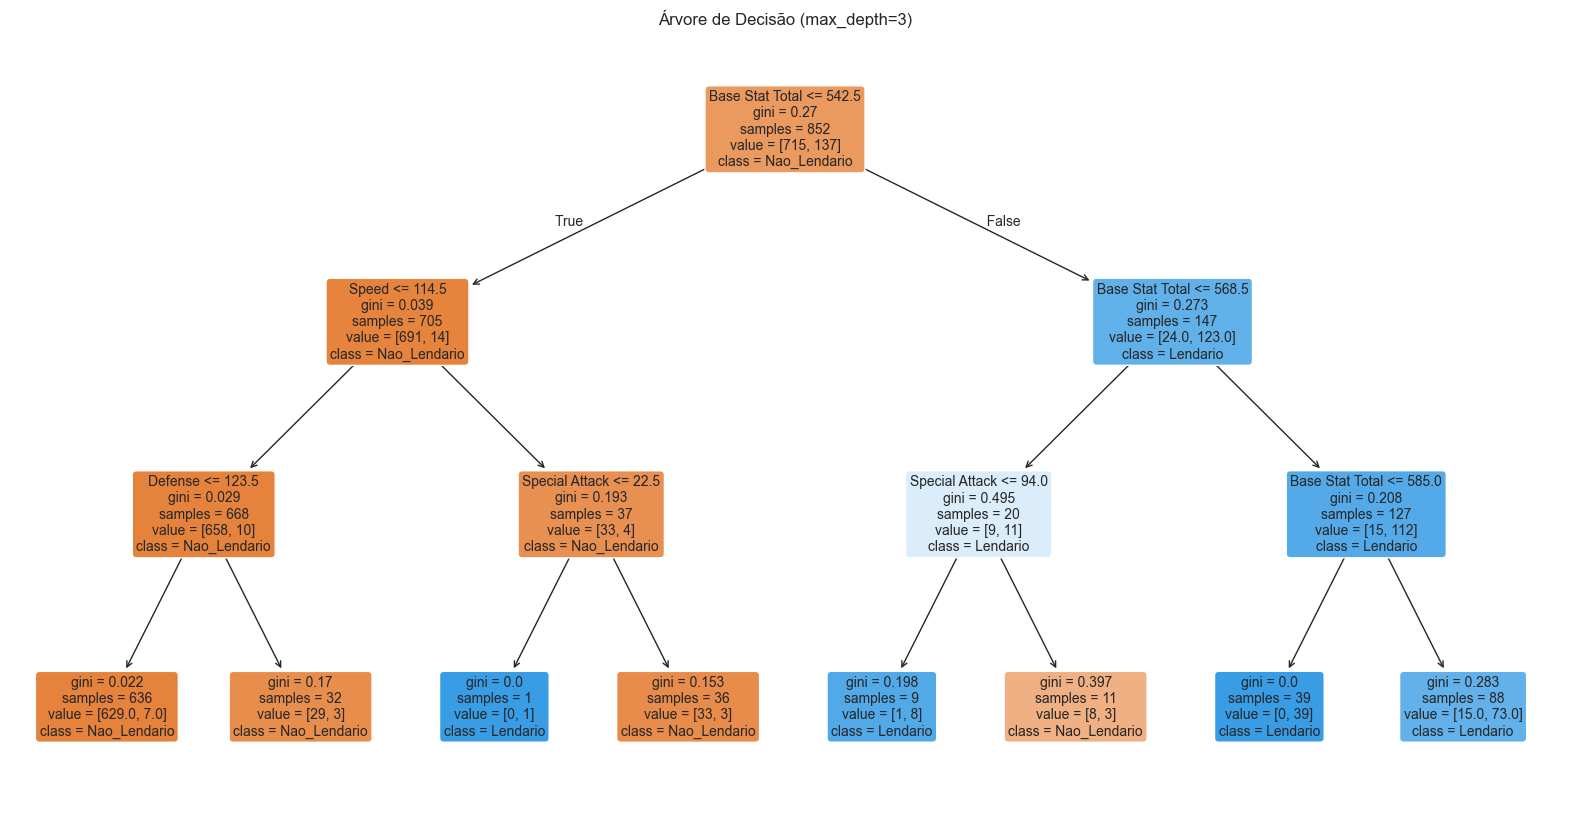

In [63]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    modelo_arvore_v1, 
    feature_names=features, 
    class_names=['Nao_Lendario', 'Lendario'], # Nossas classes
    filled=True, # Colorir os nós
    fontsize=10,
    rounded=True
)
plt.title("Árvore de Decisão (max_depth=3)")
plt.show()

_(Este gráfico mostrará visualmente as "perguntas" que o modelo aprendeu, como `Base Stat Total <= 587.5`)_

### 3.3. Medindo o Sucesso (Métricas de Classificação)

Ok, mas como sabemos se essa árvore é boa? Precisamos de métricas. A principal ferramenta é a **Matriz de Confusão**.

A estrutura básica de uma matriz de confusão 2x2 é assim:

||**Previsto: Negativo**|**Previsto: Positivo**|
|---|---|---|
|**Real: Negativo**|Verdadeiro Negativo (VN)|Falso Positivo (FP)|
|**Real: Positivo**|Falso Negativo (FN)|Verdadeiro Positivo (VP)|

#### Os Quatro Componentes da Matriz

Aqui está o significado de cada um desses termos, que são a chave para entender tudo:

##### 1. Verdadeiro Positivo (VP ou TP - _True Positive_)

- **O que é:** O modelo previu "Positivo" e o valor real _era_ "Positivo".
    
- **Tradução:** O modelo **acertou** que era positivo.
    
- **Exemplo (Pokémon):** O Pokémon _era_ Lendário e o modelo _corretamente_ o classificou como Lendário.
    

##### 2. Verdadeiro Negativo (VN ou TN - _True Negative_)

- **O que é:** O modelo previu "Negativo" e o valor real _era_ "Negativo".
    
- **Tradução:** O modelo **acertou** que era negativo.
    
- **Exemplo (Pokémon):** O Pokémon _não era_ Lendário e o modelo _corretamente_ o classificou como Não Lendário.
    

Até aqui, tudo bem. VP e VN são os **acertos** do modelo. Agora, vamos aos **erros**:

##### 3. Falso Positivo (FP ou _False Positive_) - Erro Tipo I

- **O que é:** O modelo previu "Positivo", mas o valor real era "Negativo".
    
- **Tradução:** O modelo **errou**, achando que era positivo quando não era. É um "alarme falso".
    
- **Exemplo (Pokémon):** O Pokémon _não era_ Lendário (ex: um Rattata), mas o modelo _incorretamente_ o classificou como Lendário.
    

##### 4. Falso Negativo (FN ou _False Negative_) - Erro Tipo II

- **O que é:** O modelo previu "Negativo", mas o valor real era "Positivo".
    
- **Tradução:** O modelo **errou**, achando que era negativo quando não era. Ele "deixou passar".
    
- **Exemplo (Pokémon):** O Pokémon _era_ Lendário (ex: Mewtwo), mas o modelo _incorretamente_ o classificou como Não Lendário.
    

### Métricas Baseadas na Matriz de Confusão

A partir desses 4 números, calculamos as métricas que realmente importam.

#### 1. Acurácia (Accuracy)

- **O que é?** A métrica mais intuitiva. É a porcentagem de previsões corretas (acertos) em relação ao total de previsões.
    
- **A Fórmula:**
    
    $$(VP + VN) / (VP + VN + FP + FN)$$
- **Tradução:** "O modelo acertou quantos % das vezes, no geral?"
    
- **Onde falha (Cuidado!):** A acurácia é **extremamente enganosa** em datasets desbalanceados. Nosso dataset de Pokémon tem muito mais Não-Lendários do que Lendários. Se um modelo "preguiçoso" prever **"Não-Lendário" para todo mundo**, ele terá uma acurácia altíssima (ex: 90%), mas será um modelo inútil, pois falhou em identificar _um único_ Lendário.
    

#### 2. Precisão (Precision)

- **O que é?** Das vezes que o modelo previu "Positivo" (Lendário), quantas vezes ele _realmente_ acertou?
    
- **A Fórmula:**
    
    $$(VP) / (VP + FP)$$
- **Tradução:** "Quando o modelo diz que é Lendário, qual a chance dele estar correto?"
    
- **Onde é boa:** Quando o **custo de um Falso Positivo (FP) é alto**. (Ex: Nosso modelo "chuta" que um Pidgey é Lendário. Isso é um erro feio. Queremos alta precisão).
    

#### 3. Recall (Revocação ou Sensibilidade)

- **O que é?** De todos os Pokémon que _eram realmente Lendários_, quantos o modelo conseguiu encontrar?
    
- **A Fórmula:**
    
    $$(VP) / (VP + FN)$$
- **Tradução:** "O modelo conseguiu encontrar quantos % de todos os Lendários?"
    
- **Onde é boa:** Quando o **custo de um Falso Negativo (FN) é alto**. (Ex: Deixar um Lendário passar batido como se fosse comum. Para o Professor Carvalho, isso é um erro grave!).
    

> **O Dilema (Trade-off): Precisão vs. Recall**
> 
> Em machine learning, você quase sempre precisa escolher entre Precisão e Recall.
> 
> - Aumentar a **Precisão** (ser mais rigoroso) geralmente diminui o **Recall** (encontra menos casos).
>     
> - Aumentar o **Recall** (ser mais "sensível") geralmente diminui a **Precisão** (comete mais alarmes falsos).
>     
> 
> É aqui que entra o F1-Score.

#### 4. F1-Score (Pontuação F1)

- **O que é?** A **média harmônica** de Precisão e Recall. É uma métrica única que busca um equilíbrio entre as duas.
    
- **A Fórmula:**
    
    $$2 * (Precisão * Recall) / (Precisão + Recall)$$
- **Tradução:** "Considerando o equilíbrio entre a 'qualidade' das previsões positivas (Precisão) e a 'quantidade' de positivos encontrados (Recall), qual a nota do modelo?"
    
- **Onde é boa:** Esta é, frequentemente, a **melhor métrica** para começar quando você tem classes desbalanceadas (como no nosso caso). Ela penaliza os modelos que falham muito em FN ou FP.
    

|**Métrica**|**O que mede?**|**Quando usar?**|**Principal Armadilha**|
|---|---|---|---|
|**Acurácia**|Acertos totais|Classes balanceadas.|Muito enganosa em classes desbalanceadas.|
|**Precisão**|Qualidade das previsões positivas|Custo de Falso Positivo (FP) é alto.|Ignora os Falsos Negativos (FN).|
|**Recall**|Capacidade de "encontrar" os positivos|Custo de Falso Negativo (FN) é alto.|Ignora os Falsos Positivos (FP).|
|**F1-Score**|Equilíbrio entre Precisão e Recall|Classes desbalanceadas. Ambos (FP e FN) são ruins.|Não é fácil de interpretar. Ignora os VN.|

### 3.4. Implementação (Métricas)

Vamos ver o desempenho do nosso `modelo_arvore_v1` no nosso "simulado" (dados de **validação**).

--- Relatório de Classificação (Validação V1 - max_depth=3) ---
Acurácia: 0.9812206572769953
Precisão: 0.9743589743589743
Recall: 0.926829268292683
F1-Score: 0.95
--- Matriz de Confusão (Validação V1) ---


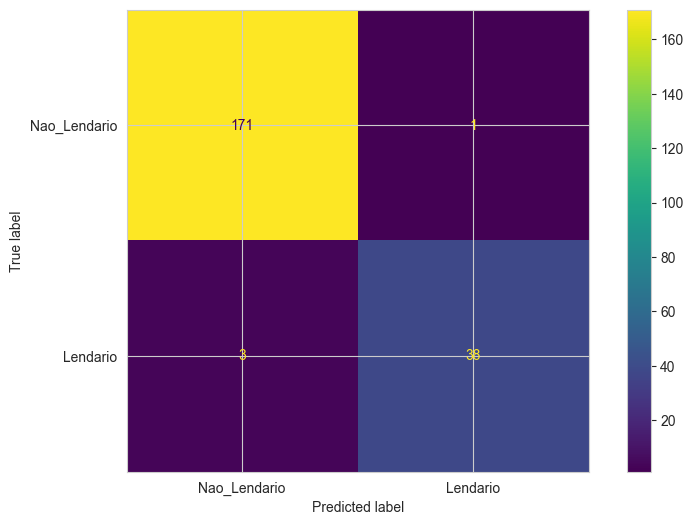

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

# 1. Fazer previsões nos dados de VALIDAÇÃO
y_pred_val = modelo_arvore_v1.predict(X_val)

# 2. Gerar o Relatório de Classificação
print("--- Relatório de Classificação (Validação V1 - max_depth=3) ---")
print(f'Acurácia: {accuracy_score(y_val, y_pred_val)}')
print(f'Precisão: {precision_score(y_val, y_pred_val)}')
print(f'Recall: {recall_score(y_val, y_pred_val)}')
print(f'F1-Score: {f1_score(y_val, y_pred_val)}')

# 3. Plotar a Matriz de Confusão
print("--- Matriz de Confusão (Validação V1) ---")
ConfusionMatrixDisplay.from_estimator(
    modelo_arvore_v1, X_val, y_val,
    display_labels=['Nao_Lendario', 'Lendario']
)
plt.show()


_(Aqui, vamos analisar os resultados. Ex: "Nosso F1-Score para Lendário foi X... será que podemos melhorar? Vamos tentar um `max_depth=5`...")_

In [66]:
# --- Testando Hiperparâmetro V2 ---
modelo_arvore_v2 = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arvore_v2.fit(X_train, y_train)

print("--- Relatório V2 (max_depth=5) ---")
y_pred_val_v2 = modelo_arvore_v2.predict(X_val)
print(f'Acurácia: {accuracy_score(y_val, y_pred_val_v2)}')
print(f'Precisão: {precision_score(y_val, y_pred_val_v2)}')
print(f'Recall: {recall_score(y_val, y_pred_val_v2)}')
print(f'F1-Score: {f1_score(y_val, y_pred_val_v2)}')

--- Relatório V2 (max_depth=5) ---
Acurácia: 0.9859154929577465
Precisão: 0.975
Recall: 0.9512195121951219
F1-Score: 0.9629629629629629


**Nota Final (Teste):** "Ok, o `modelo_arvore_v2` (max_depth=5) foi o campeão no nosso simulado. Agora, e somente agora, vamos ver a nota dele na 'prova final', o conjunto de **Teste**."

In [68]:
y_pred_test = modelo_arvore_v2.predict(X_test)
print("--- DESEMPENHO FINAL NO TESTE (max_depth=5) ---")
print(f'Acurácia: {accuracy_score(y_test, y_pred_test)}')
print(f'Precisão: {precision_score(y_test, y_pred_test)}')
print(f'Recall: {recall_score(y_test, y_pred_test)}')
print(f'F1-Score: {f1_score(y_test, y_pred_test)}')

--- DESEMPENHO FINAL NO TESTE (max_depth=5) ---
Acurácia: 0.9663865546218487
Precisão: 0.8636363636363636
Recall: 0.95
F1-Score: 0.9047619047619048


### Análise de Sobrevivência do Titanic (Classificação)

- **Dataset:** Titanic (do `seaborn`)
    
- **Tarefa:** Prever se `survived` (0 ou 1).
    
- **Passos:**
    
    1. `df_titanic = sns.load_dataset('titanic')`
        
    2. **Limpeza:** `df_titanic = df_titanic[['pclass', 'age', 'fare', 'survived']].dropna()` (Vamos usar só essas colunas por enquanto)
        
    3. **Definir X e y:** `X` (`['pclass', 'age', 'fare']`) e `y` (`['survived']`).
        
    4. **Dividir:** Faça o `train_test_split` (em treino, validação e teste).
        
    5. **Modele:** Treine uma `DecisionTreeClassifier`.
        
    6. **Avalie:** Gere o `classification_report` e a `ConfusionMatrixDisplay` nos dados de **validação**.
        
    7. **Analise:** O que é mais importante aqui, Precisão ou Recall? (Dica: O que é um Falso Negativo neste caso? É um erro grave "deixar passar" um sobrevivente ou prever erroneamente que alguém sobreviveu?)